# Climate Transition Risk and Sovereign Debt Sustainability

**How do climate change damages, adaptation costs, and decarbonization tax policies shape long-term public debt sustainability?**

Fiscal authorities and central banks increasingly recognize that climate change is a macro-fiscal risk:
1. **Damage Channel**: Rising global temperatures reduce labor productivity and capital efficiency, shrinking the aggregate tax base.
2. **Adaptation Expenditure Channel**: Higher warming necessitates rising public spending on sea walls, disaster relief, and grid hardening.
3. **Risk Premium Channel**: Sovereign bond yields price in climate vulnerability and fiscal deterioration via higher credit spreads:
   $$ r_t = r^* + \psi_{debt} \max(0, b_t - 0.60) + \psi_{clim} T_t $$
4. **Revenue Recycling Channel**: Predictable carbon pricing generates fiscal revenues that can amortize debt and fund green infrastructure.

In this interactive showcase, we simulate long-term sovereign debt dynamics coupled to the **DICE climate-macro model** using `puremacro.climate`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.climate import simulate_dice_model

## 1. Simulating 3 Policy Regimes in the DICE Model

We compare:
- **Unabated Warming**: No carbon tax ($\tau = 0$), higher climate damage coefficient.
- **Disorderly Late Transition**: Weak initial policy ($\tau = \$10/t$) with late abrupt tightening.
- **Orderly Green Fiscal Rule**: Predictable carbon tax ($\tau = \$60/t, +3\%/\text{year}$) with active mitigation.

In [2]:
# 1. Unabated Warming
dice_unabated = simulate_dice_model(
    n_periods=25,
    time_step_years=5,
    carbon_tax_initial=0.0,
    carbon_tax_growth=0.0,
    damage_coef=0.0035,
)

# 2. Disorderly Late Transition
dice_late = simulate_dice_model(
    n_periods=25,
    time_step_years=5,
    carbon_tax_initial=10.0,
    carbon_tax_growth=0.01,
    damage_coef=0.0028,
)

# 3. Orderly Green Fiscal Transition
dice_orderly = simulate_dice_model(
    n_periods=25,
    time_step_years=5,
    carbon_tax_initial=60.0,
    carbon_tax_growth=0.03,
    damage_coef=0.00236,
)

print("Orderly Scenario Preview:")
print(dice_orderly.summary())

Orderly Scenario Preview:
DICE-2016R forward simulation (Nordhaus 2017)
Horizon                         : 25 periods of 5 years, 2020-2140
Initial Social Cost of Carbon   : $34.03 / tCO2  (rho = 0.015, eta = 1.45)
Peak Global Surface Warming     : 3.22 degC above pre-industrial
End-Century (2100) Damage Share : 2.04% of gross output
------------------------------------------------------------------------
Key Benchmark Years (nearest available row):
  Year 2025: Temp +1.27degC | Emissions 31.0 GtCO2/yr | Damage 0.38% | Tax $69.6/t | SCC $39.0/t
  Year 2050: Temp +1.93degC | Emissions 29.2 GtCO2/yr | Damage 0.87% | Tax $145.6/t | SCC $77.0/t
  Year 2075: Temp +2.54degC | Emissions 12.0 GtCO2/yr | Damage 1.52% | Tax $304.9/t | SCC $138.2/t
  Year 2100: Temp +2.94degC | Emissions 0.4 GtCO2/yr | Damage 2.04% | Tax $638.5/t | SCC $226.9/t


## 2. Sovereign Debt Dynamics & Fiscal Feedback Function

In [3]:
def simulate_sovereign_fiscal_risk(
    dice_res,
    initial_debt_gdp: float = 0.60,
    base_tax_rate: float = 0.20,
    base_spending_rate: float = 0.19,
    adapt_cost_coef: float = 0.0015,
    spread_debt_coef: float = 0.03,
    spread_climate_coef: float = 0.005,
    r_star: float = 0.02,
) -> pd.DataFrame:
    df = dice_res.trajectories.copy()
    years = list(df.index)
    dt = 5

    debt_gdp, rates, adaptation = [], [], []
    B_over_Y = initial_debt_gdp

    for yr in years:
        row = df.loc[yr]
        T_clim = row["temperature_anomaly"]
        Y_net = row["output_net"]
        carbon_tax_rev = (row["social_cost_of_carbon"] * row["emissions"] * 1e-3) / Y_net

        g_adapt = adapt_cost_coef * (T_clim ** 2)
        pb = (base_tax_rate + carbon_tax_rev) - (base_spending_rate + g_adapt)
        r_sovereign = r_star + spread_debt_coef * max(0.0, B_over_Y - 0.60) + spread_climate_coef * T_clim

        debt_gdp.append(B_over_Y * 100.0)
        rates.append(r_sovereign * 100.0)
        adaptation.append(g_adapt * 100.0)

        B_over_Y = max(0.0, (1.0 + (r_sovereign - 0.015) * dt) * B_over_Y - pb * dt)

    return pd.DataFrame({
        "year": years,
        "debt_to_gdp": debt_gdp,
        "sovereign_rate": rates,
        "adaptation_cost": adaptation,
        "temperature_anomaly": df["temperature_anomaly"].values,
    }).set_index("year")

fiscal_unabated = simulate_sovereign_fiscal_risk(dice_unabated)
fiscal_late = simulate_sovereign_fiscal_risk(dice_late)
fiscal_orderly = simulate_sovereign_fiscal_risk(dice_orderly)

## 3. Sovereign Debt-to-GDP and Borrowing Rates

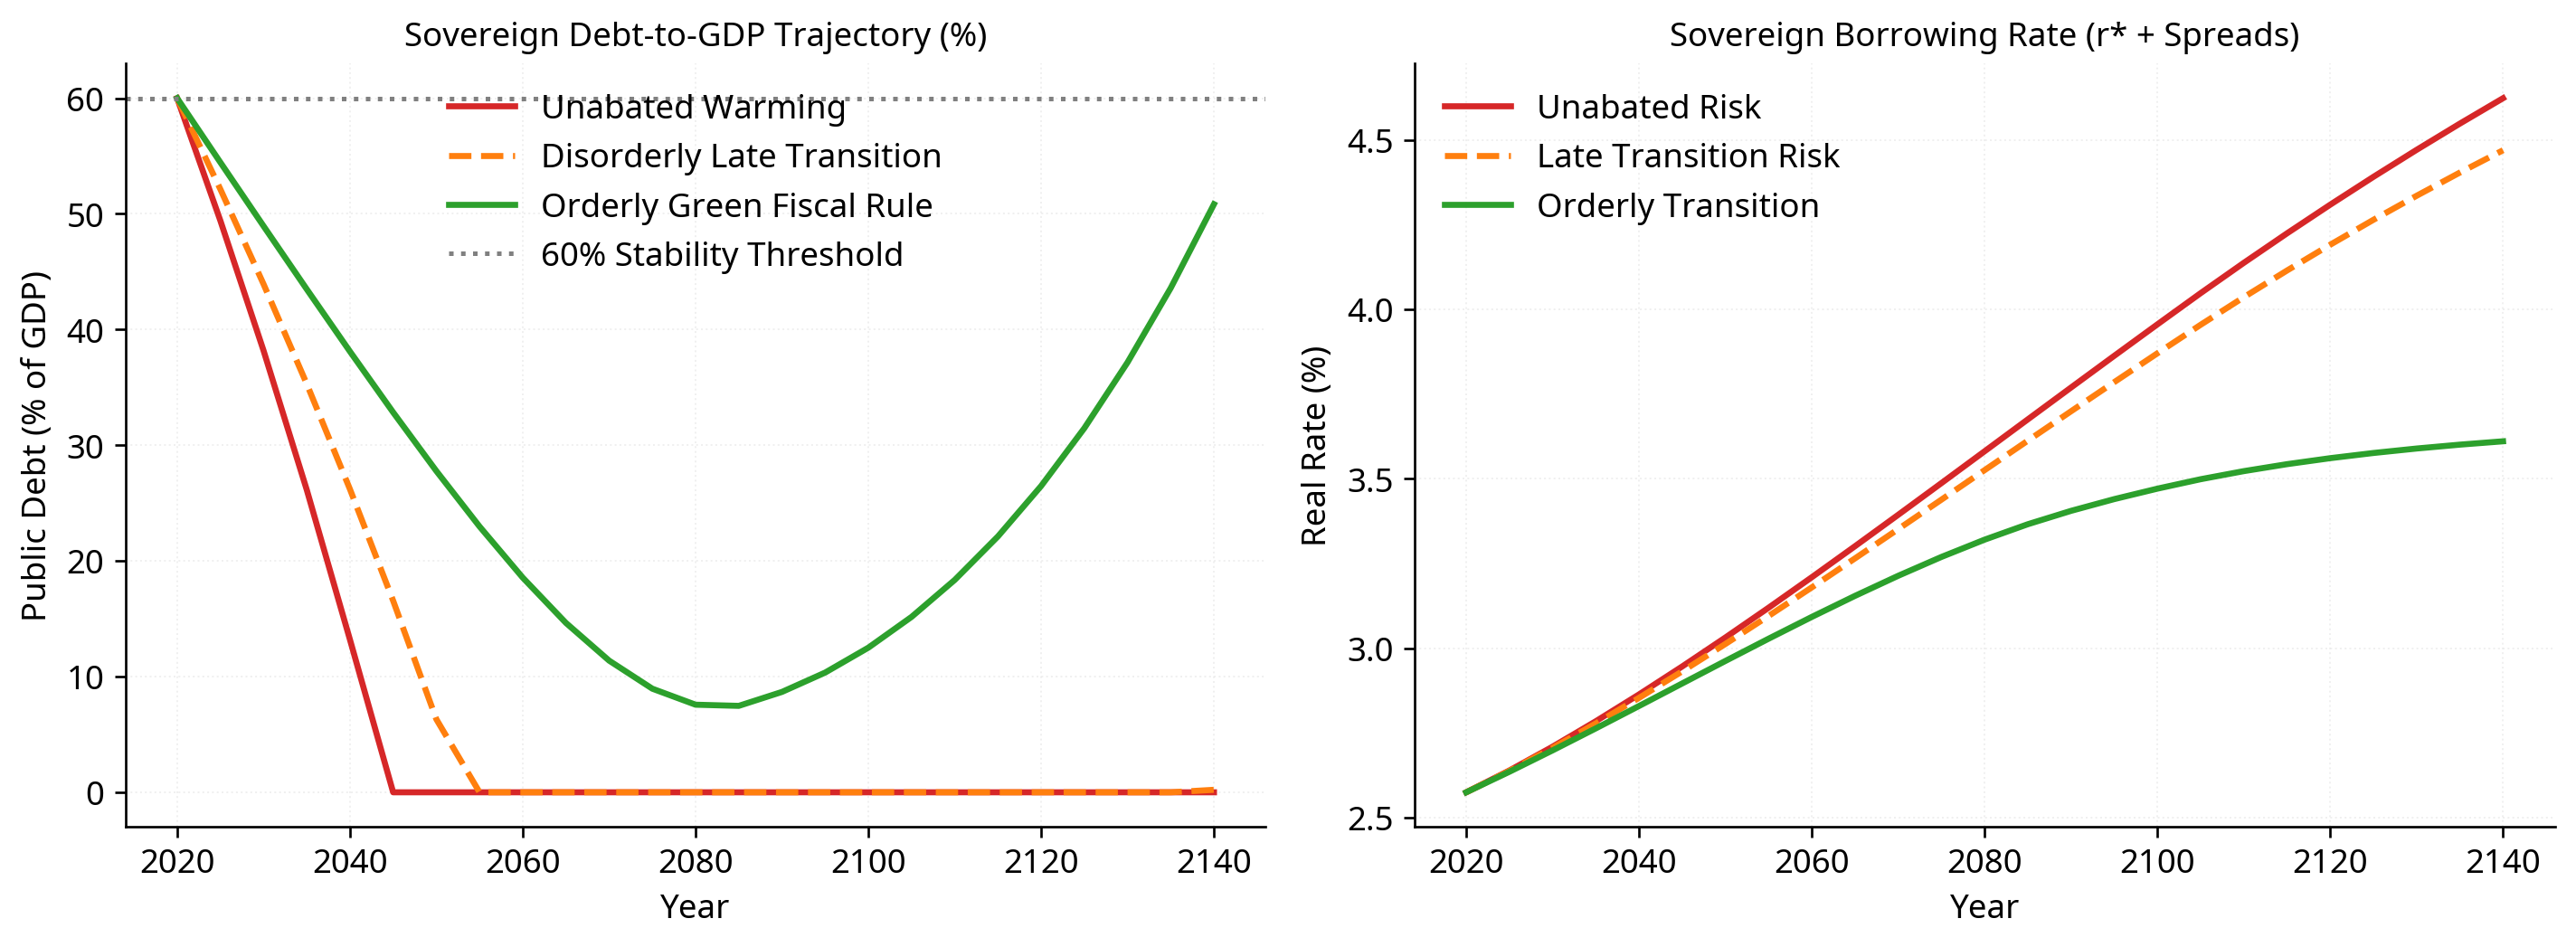

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(fiscal_unabated.index, fiscal_unabated["debt_to_gdp"], color="#d62728", lw=2, label="Unabated Warming")
ax1.plot(fiscal_late.index, fiscal_late["debt_to_gdp"], color="#ff7f0e", lw=2, linestyle="--", label="Disorderly Late Transition")
ax1.plot(fiscal_orderly.index, fiscal_orderly["debt_to_gdp"], color="#2ca02c", lw=2, label="Orderly Green Fiscal Rule")
ax1.axhline(60, color="gray", linestyle=":", label="60% Stability Threshold")
ax1.set_title("Sovereign Debt-to-GDP Trajectory (%)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Year")
ax1.set_ylabel("Public Debt (% of GDP)")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

ax2.plot(fiscal_unabated.index, fiscal_unabated["sovereign_rate"], color="#d62728", lw=2, label="Unabated Risk")
ax2.plot(fiscal_late.index, fiscal_late["sovereign_rate"], color="#ff7f0e", lw=2, linestyle="--", label="Late Transition Risk")
ax2.plot(fiscal_orderly.index, fiscal_orderly["sovereign_rate"], color="#2ca02c", lw=2, label="Orderly Transition")
ax2.set_title("Sovereign Borrowing Rate (r* + Spreads)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Year")
ax2.set_ylabel("Real Rate (%)")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Adaptation Costs and Surface Warming

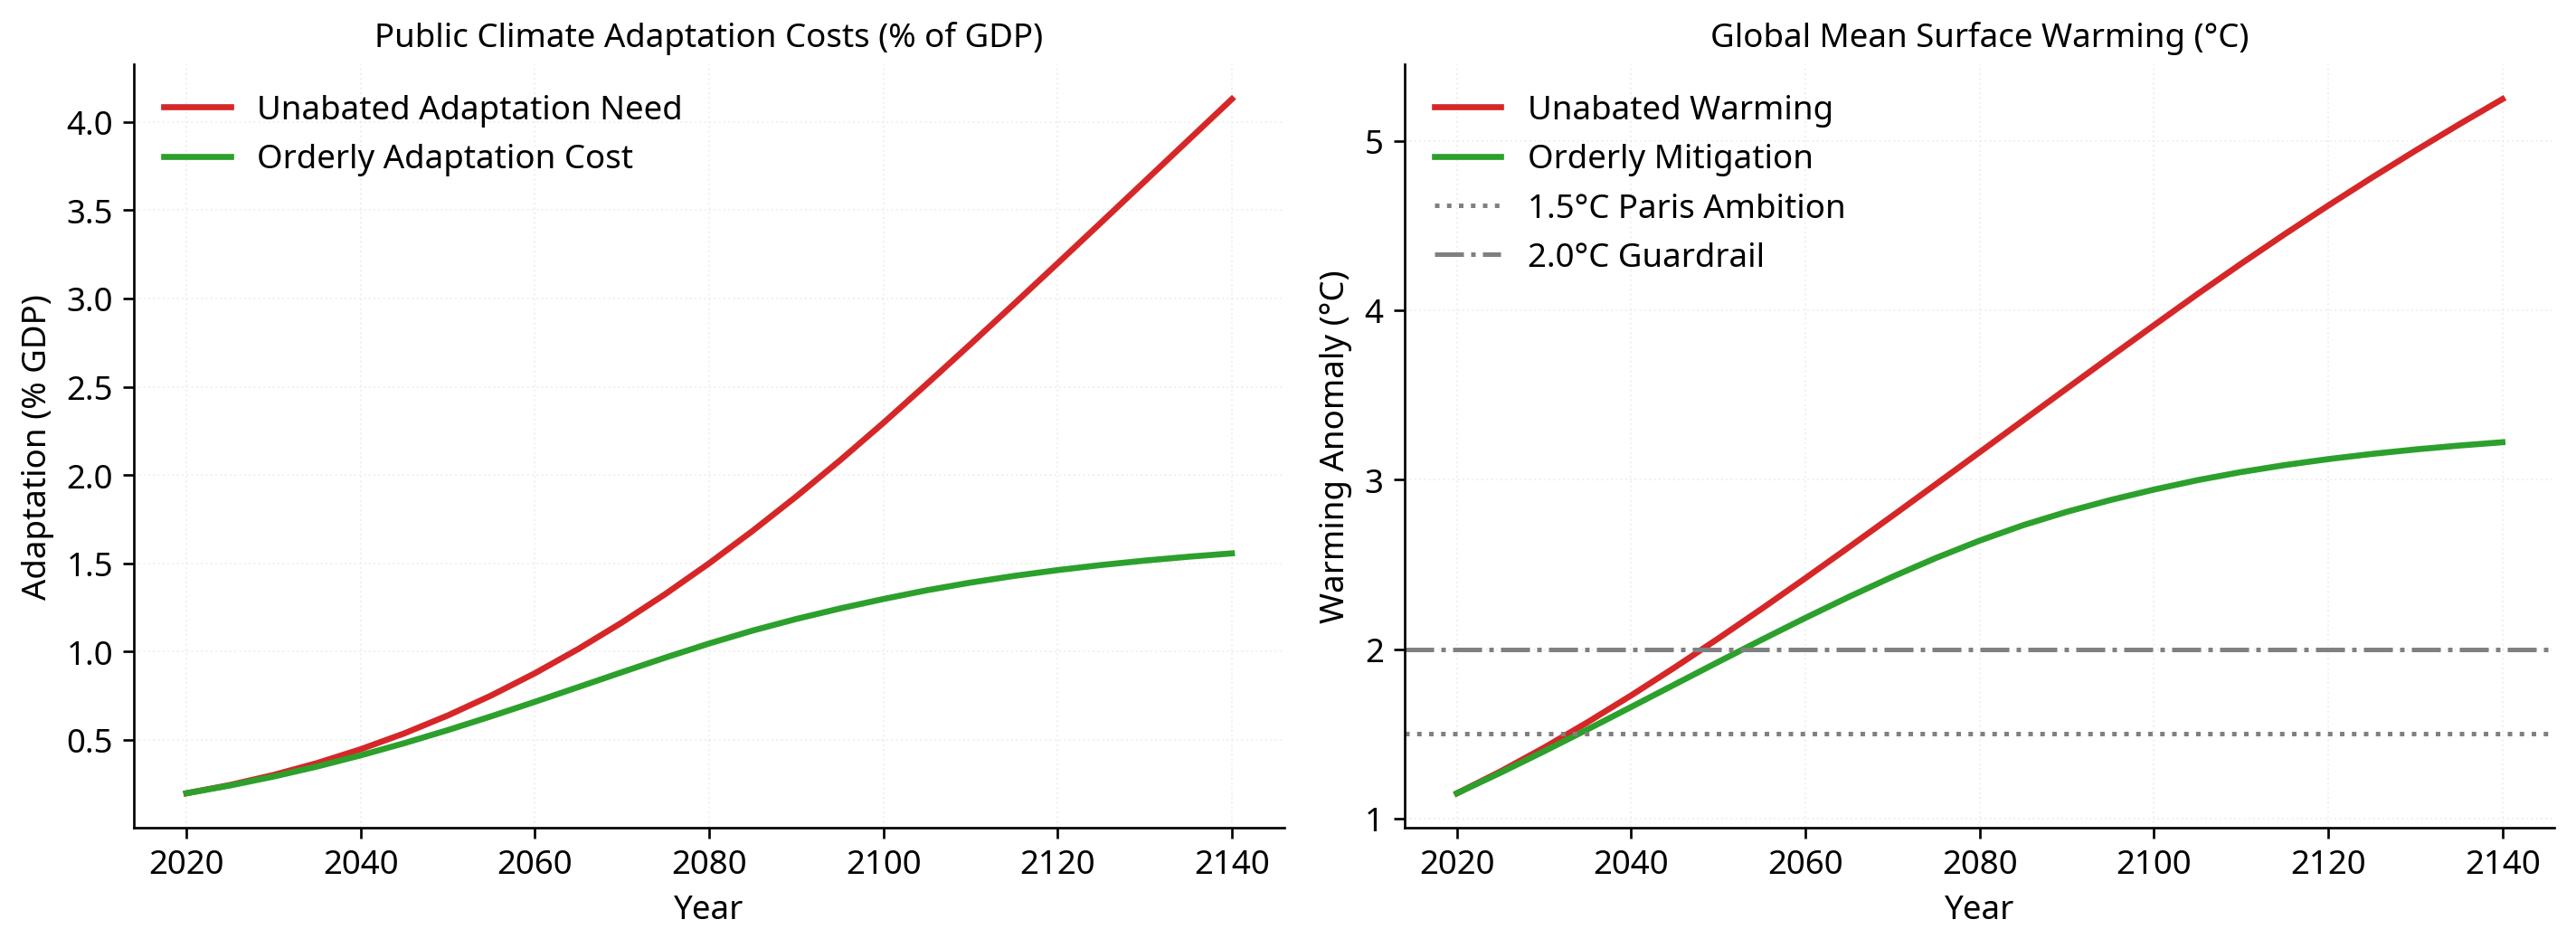

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(fiscal_unabated.index, fiscal_unabated["adaptation_cost"], color="#d62728", lw=2, label="Unabated Adaptation Need")
ax1.plot(fiscal_orderly.index, fiscal_orderly["adaptation_cost"], color="#2ca02c", lw=2, label="Orderly Adaptation Cost")
ax1.set_title("Public Climate Adaptation Costs (% of GDP)", fontsize=11, fontweight="bold")
ax1.set_xlabel("Year")
ax1.set_ylabel("Adaptation (% GDP)")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

ax2.plot(fiscal_unabated.index, fiscal_unabated["temperature_anomaly"], color="#d62728", lw=2, label="Unabated Warming")
ax2.plot(fiscal_orderly.index, fiscal_orderly["temperature_anomaly"], color="#2ca02c", lw=2, label="Orderly Mitigation")
ax2.axhline(1.5, color="gray", linestyle=":", label="1.5°C Paris Ambition")
ax2.axhline(2.0, color="gray", linestyle="-.", label="2.0°C Guardrail")
ax2.set_title("Global Mean Surface Warming (°C)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Year")
ax2.set_ylabel("Warming Anomaly (°C)")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()